# =============================================================
# Revenue Optimization through Dynamic Pricing 
# and Inventory Constraints
# =============================================================
## Dataset:  Walmart M5 Forecasting (Kaggle)
## Author:   Özlem Albayrak
## Date:     March 2026
---
# Overview:
### This project estimates price elasticity of demand for food
### products across Walmart stores, builds a demand forecasting
### model, and simulates dynamic pricing decisions to maximize
### revenue under inventory constraints.
---
# Pipeline:
###   1. Data Preparation & Feature Engineering
###   2. Price Elasticity Estimation (OLS Panel Model)
###   3. Demand Forecasting (LightGBM)
###   4. Revenue Optimization (Price Optimizer)
###   5. Inventory Constraints Simulation
###   6. Interactive Web App (Streamlit)
# =============================================================
### Demand Forecasting (LightGBM)

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

# machine-learning stack
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    KBinsDiscretizer,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# miscellaneous
import warnings
warnings.filterwarnings("ignore")

In [2]:
sell_prices=pd.read_csv('data/sell_prices.csv')
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [3]:
df=pd.read_csv('data/wallmart_food_top150.csv', parse_dates=['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291150 entries, 0 to 291149
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    291150 non-null  int64         
 1   id            291150 non-null  object        
 2   item_id       291150 non-null  object        
 3   dept_id       291150 non-null  object        
 4   cat_id        291150 non-null  object        
 5   store_id      291150 non-null  object        
 6   state_id      291150 non-null  object        
 7   d             291150 non-null  object        
 8   sales         291150 non-null  int64         
 9   date          291150 non-null  datetime64[ns]
 10  wm_yr_wk      291150 non-null  int64         
 11  weekday       291150 non-null  object        
 12  wday          291150 non-null  int64         
 13  month         291150 non-null  int64         
 14  year          291150 non-null  int64         
 15  event_name_1  237

In [4]:
df.columns

Index(['Unnamed: 0', 'id', 'item_id', 'dept_id', 'cat_id', 'store_id',
       'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'wday',
       'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2',
       'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price'],
      dtype='object')

In [5]:
# 1. Prepare data
def prepare_data(df):

    df = df.copy()

    # remove csv index column if present
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")

    # ensure date format
    df["date"] = pd.to_datetime(df["date"])

    # sort panel for lag features
    df = df.sort_values(["store_id", "item_id", "date"]).reset_index(drop=True)

    return df

# 2. SNAP feature
def add_snap_feature(df):

    df = df.copy()

    df["snap"] = 0

    df.loc[df["state_id"] == "CA", "snap"] = df.loc[df["state_id"] == "CA", "snap_CA"]
    df.loc[df["state_id"] == "TX", "snap"] = df.loc[df["state_id"] == "TX", "snap_TX"]
    df.loc[df["state_id"] == "WI", "snap"] = df.loc[df["state_id"] == "WI", "snap_WI"]

    df["snap"] = df["snap"].astype("int8")

    return df

# 3. Event features
def clean_event_features(df):

    df = df.copy()

    df["event_name_1"] = df["event_name_1"].fillna("No_Event")
    df["event_name_2"] = df["event_name_2"].fillna("No_Event")

    # binary event indicator
    df["has_event"] = (
        (df["event_name_1"] != "No_Event") |
        (df["event_name_2"] != "No_Event")
    ).astype("int8")

    return df

# 4. Calendar features
def add_calendar_features(df):

    df = df.copy()

    df["day_of_month"] = df["date"].dt.day
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = (df["date"].dt.dayofweek >= 5).astype(int)

    return df

# 5. Lag features
def add_lag_features(df):

    df = df.copy()

    group = df.groupby(["store_id", "item_id"])["sales"]
    df["sales_lag_1"] = group.shift(1)
    df["sales_lag_7"] = group.shift(7)
    df["sales_lag_14"] = group.shift(14)
    df["sales_lag_28"] = group.shift(28)

    return df

# 6. Rolling demand features
def add_rolling_features(df):
    df = df.copy()

    group = df.groupby(["store_id", "item_id"])["sales"]

    shifted = group.shift(1)

    df["sales_roll_mean_7"] = shifted.groupby([df["store_id"], df["item_id"]]).transform(
        lambda x: x.rolling(7).mean()
    )
    df["sales_roll_mean_28"] = shifted.groupby([df["store_id"], df["item_id"]]).transform(
        lambda x: x.rolling(28).mean()
    )
    df["sales_roll_std_28"] = shifted.groupby([df["store_id"], df["item_id"]]).transform(
        lambda x: x.rolling(28).std()
    )

    return df
"""
# 7. Demand momentum
def add_momentum_feature(df):

    df = df.copy()

    df["sales_momentum"] = df["sales_lag_7"] / (df["sales_lag_28"] + 1)

    return df """

# 8. Price features
def add_price_features(df):

    df = df.copy()

    group = df.groupby(["store_id", "item_id"])["sell_price"]

    df["price_lag_1"] = group.shift(1)

    df["price_change_1"] = df["sell_price"] - df["price_lag_1"]

    df["price_pct_change_1"] = (df["sell_price"] / df["price_lag_1"]) - 1

    df["price_roll_mean_28"] = group.transform(lambda x: x.shift(1).rolling(28).mean())

    df["price_rel"] = df["sell_price"] / df["price_roll_mean_28"]

    return df

# 9. Convert categorical features into right type(Category)

def make_category(df):
    df = df.copy()

    cat_features = [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "weekday",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2"
    ]

    for col in cat_features:
        df[col] = df[col].astype("category")

    return df
        

In [6]:
# 9. Build full feature set
def build_features(df):

    df = prepare_data(df)
    df = add_snap_feature(df)
    df = clean_event_features(df)
    df = add_calendar_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)
    #df = add_momentum_feature(df)
    df = add_price_features(df)
    df = make_category(df)

    # only drop rows where key engineered features are missing
    needed_cols = [
        "sales_lag_1",
        "sales_lag_7",
        "sales_lag_14",
        "sales_lag_28",
        "sales_roll_mean_7",
        "sales_roll_mean_28",
        "sales_roll_std_28",
        #"sales_momentum",
        "price_lag_1",
        "price_change_1",
        "price_pct_change_1",
        "price_roll_mean_28",
        "price_rel",
    ]

    df = df.dropna(subset=needed_cols)

    return df

In [7]:

# 10. Train test split
def time_split(df, test_days=84):

    max_date = df["date"].max()

    split_date = max_date - pd.Timedelta(days=test_days)

    train = df[df["date"] <= split_date].copy()

    test = df[df["date"] > split_date].copy()

    print(f"train data: {train['date'].min()} - {train['date'].max()}")
    print(f"test data: {test['date'].min()} - {test['date'].max()}")

    return train, test

# 11. Select features
def get_features(df):

    exclude = ["sales", "date", "d", "id", "Unnamed: 0"]

    features = [c for c in df.columns if c not in exclude]

    return features



In [8]:
df = build_features(df)
print(f"df_shape: {df.shape}")
train, test = time_split(df)
print(f"train_shape: {train.shape} ,  test_shape: {test.shape}")
features = get_features(train)

X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

df_shape: (279208, 40)
train data: 2011-02-26 00:00:00 - 2016-02-28 00:00:00
test data: 2016-02-29 00:00:00 - 2016-05-22 00:00:00
train_shape: (266608, 40) ,  test_shape: (12600, 40)


In [9]:
print("original rows:", df.shape[0])
print("train rows:", train.shape[0])
print("test rows:", test.shape[0])

print("train unique dates:", train["date"].nunique())
print("test unique dates:", test["date"].nunique())

original rows: 279208
train rows: 266608
test rows: 12600
train unique dates: 1829
test unique dates: 84


## LightGBM Modelling

In [10]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266608 entries, 28 to 291065
Data columns (total 36 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   item_id             266608 non-null  category
 1   dept_id             266608 non-null  category
 2   cat_id              266608 non-null  category
 3   store_id            266608 non-null  category
 4   state_id            266608 non-null  category
 5   wm_yr_wk            266608 non-null  int64   
 6   weekday             266608 non-null  category
 7   wday                266608 non-null  int64   
 8   month               266608 non-null  int64   
 9   year                266608 non-null  int64   
 10  event_name_1        266608 non-null  category
 11  event_type_1        21566 non-null   category
 12  event_name_2        266608 non-null  category
 13  event_type_2        581 non-null     category
 14  snap_CA             266608 non-null  int64   
 15  snap_TX             2

In [11]:
 cat_features = [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "weekday",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2"
    ]

In [12]:
#!pip install lightgbm==4.5.0

In [13]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
import numpy as np

baseline_model = LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

#bestparams:{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'n_estimators': 500, 'num_leaves': 64, 'subsample': 0.8}
baseline_model.fit(
    X_train,
    y_train,
    categorical_feature=cat_features
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3120
[LightGBM] [Info] Number of data points in the train set: 266608, number of used features: 35
[LightGBM] [Info] Start training from score 28.252408


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,300
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
#import sys
#!{sys.executable} -m pip install lightgbm==4.5.0

In [15]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def relative_rmse(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse / np.mean(y_test)


def rmse(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse


def mae(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    return mae

In [16]:
baseline_pred = baseline_model.predict(X_test)

## EVALUATION

In [17]:
df_test = X_test.copy()

# attach actual and predicted sales
df_test["sales"] = y_test
df_test["sales_pred"] = baseline_pred

In [18]:
baseline_pred.shape

(12600,)

In [19]:
df_test.shape

(12600, 38)

In [20]:
import numpy as np
import pandas as pd

df_test = X_test.reset_index(drop=True).copy()
df_test["sales"] = y_test.reset_index(drop=True)
df_test["sales_pred"] = np.asarray(baseline_pred)

print(df_test.shape)
print(df_test[["sales", "sales_pred"]].shape)

(12600, 38)
(12600, 2)


In [21]:
# Prices are updated weekly, so weekly performance evaluation is better for business purposes too
weekly_pred = (
    df_test
    .groupby(
        ["item_id", "store_id", "wm_yr_wk"],
        observed=True
    )
    .agg(
        sales_actual=("sales", "sum"),
        sales_pred=("sales_pred", "sum"),
        price=("sell_price", "first")
    )
    .reset_index()
)

In [22]:
weekly_pred.shape

(1950, 6)

In [23]:
weekly_pred["rev_actual"] = weekly_pred["sales_actual"] * weekly_pred["price"]
weekly_pred["rev_pred"] = weekly_pred["sales_pred"] * weekly_pred["price"]

print(
    f"Weekly Relative RMSE predicted revenues: "
    f"{relative_rmse(weekly_pred['rev_actual'], weekly_pred['rev_pred']):.3f}"
)

Weekly Relative RMSE predicted revenues: 0.172


In [24]:
#Weekly Results
rmse_sales_ols=53.163
relative_rmse_sales_ols=0.302
rmse_revenue_ols=148.792
relative_rmse_revenue_ols=0.455
mae_rev_weekly_ols=64.152
rmse_salesbase_week=round(rmse(weekly_pred["sales_actual"], weekly_pred['sales_pred']), 3)
rmse_revbase_week=round(rmse(weekly_pred["rev_actual"], weekly_pred['rev_pred']), 3)
rel_rmse_salesbase_week=round(relative_rmse(weekly_pred["sales_actual"], weekly_pred['sales_pred']), 3)
rel_rmse_revbase_week=round(relative_rmse(weekly_pred["rev_actual"], weekly_pred['rev_pred']), 3)
mae_rev_weekly= round(mae(weekly_pred['rev_actual'], weekly_pred['rev_pred']), 3)

In [25]:
results = pd.DataFrame({
    "Model": [
        "OLS", "OLS", "OLS", "OLS", "OLS",
        "LightGBM_base", "LightGBM_base", "LightGBM_base", "LightGBM_base", "LightGBM_base"
    ],
    "Metric": [
        "RMSE Sales", "Relative RMSE Sales",
        "RMSE Revenue", "Relative RMSE Revenue", "MAE Revenue",
        "RMSE Sales", "Relative RMSE Sales",
        "RMSE Revenue", "Relative RMSE Revenue", "MAE Revenue"
    ],
    "Value": [
        rmse_sales_ols,
        relative_rmse_sales_ols,
        rmse_revenue_ols,
        relative_rmse_revenue_ols,
        mae_rev_weekly_ols,
        rmse_salesbase_week,
        rel_rmse_salesbase_week,
        rmse_revbase_week,
        rel_rmse_revbase_week,
        mae_rev_weekly
    ]
})

print(results)

           Model                 Metric    Value
0            OLS             RMSE Sales   53.163
1            OLS    Relative RMSE Sales    0.302
2            OLS           RMSE Revenue  148.792
3            OLS  Relative RMSE Revenue    0.455
4            OLS            MAE Revenue   64.152
5  LightGBM_base             RMSE Sales   25.449
6  LightGBM_base    Relative RMSE Sales    0.150
7  LightGBM_base           RMSE Revenue   53.842
8  LightGBM_base  Relative RMSE Revenue    0.172
9  LightGBM_base            MAE Revenue   29.274


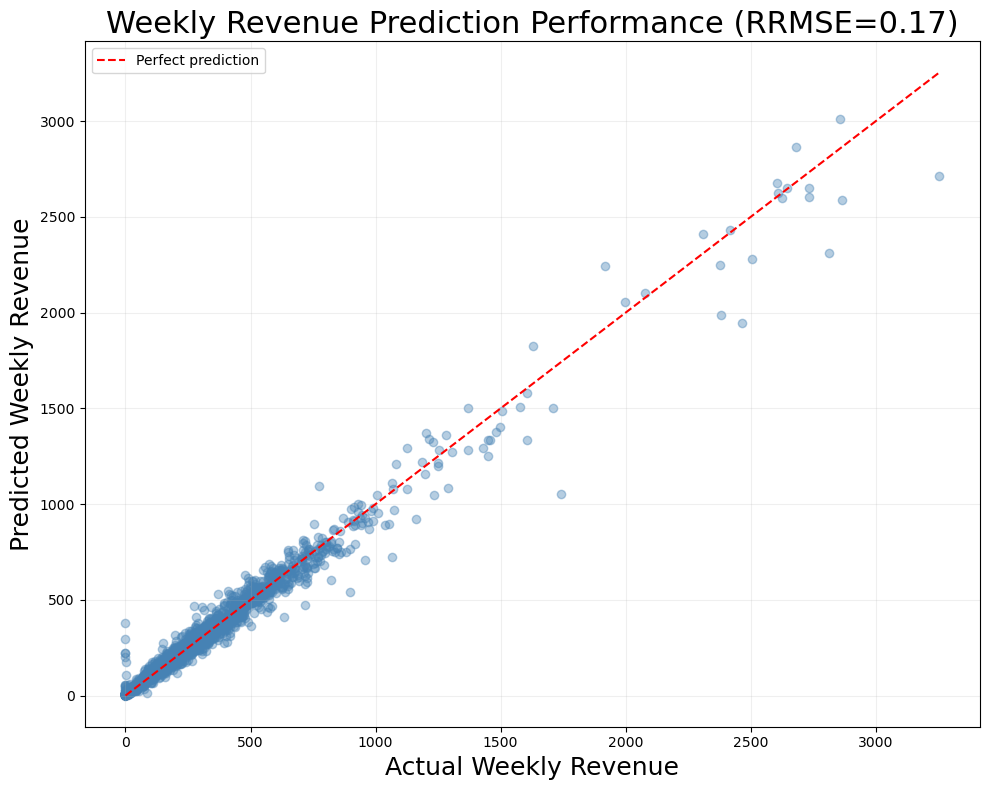

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

plt.figure(figsize=(10,8))

plt.scatter(
    weekly_pred["rev_actual"],
    weekly_pred["rev_pred"],
    alpha=0.4,
    color="steelblue"
)

# perfect prediction line
min_val = min(weekly_pred["rev_actual"].min(), weekly_pred["rev_pred"].min())
max_val = max(weekly_pred["rev_actual"].max(), weekly_pred["rev_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

#Weekly Relative RMSE predicted revenues
rel_rmse_revbase_week=round(relative_rmse(weekly_pred["rev_actual"], weekly_pred['rev_pred']), 3)

plt.xlabel("Actual Weekly Revenue", size=18)
plt.ylabel("Predicted Weekly Revenue", size=18)
plt.title(f"Weekly Revenue Prediction Performance (RRMSE={rel_rmse_revbase_week:.2f})", size=22)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig("visuals/LightGBMbaseWeeklyRevenue_Prediction_vsActual.png")

plt.show()

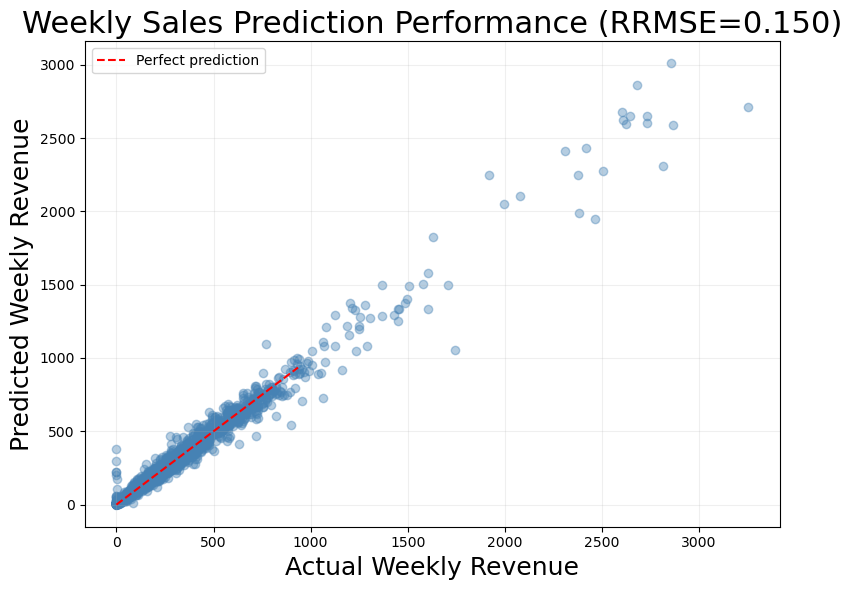

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

plt.figure(figsize=(8,6))

plt.scatter(
    weekly_pred["rev_actual"],
    weekly_pred["rev_pred"],
    alpha=0.4,
    color="steelblue"
)

# perfect prediction line
min_val = min(weekly_pred["sales_actual"].min(), weekly_pred["sales_pred"].min())
max_val = max(weekly_pred["sales_actual"].max(), weekly_pred["sales_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

#Weekly Relative RMSE predicted revenues
rel_rmse_salesbase_week=relative_rmse(weekly_pred['sales_actual'], weekly_pred['sales_pred'])

plt.xlabel("Actual Weekly Revenue", size=18)
plt.ylabel("Predicted Weekly Revenue", size=18)
plt.title(f"Weekly Sales Prediction Performance (RRMSE={rel_rmse_salesbase_week:.3f})", size=22)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig("visuals/LightGBMbaseWeeklySales_Prediction_vsActual.png", dpi=300)

plt.show()

In [28]:
weekly_pred.head()

,item_id,store_id,wm_yr_wk,sales_actual,sales_pred,price,rev_actual,rev_pred
0,FOODS_1_096,WI_2,11605,341,269.309268,7.23,2465.43,1947.106011
1,FOODS_1_096,WI_2,11606,395,416.153516,7.23,2855.85,3008.789919
2,FOODS_1_096,WI_2,11607,361,362.746451,7.23,2610.03,2622.656838
3,FOODS_1_096,WI_2,11608,450,374.984928,7.23,3253.50,2711.141031
4,FOODS_1_096,WI_2,11609,366,366.714135,7.23,2646.18,2651.343193


- The baseline LightGBM model outperformed the OLS benchmark across both sales and revenue prediction metrics. 
- Using weekly aggregation to align with the timing of price updates, LightGBM reduced Relative RMSE for sales from 0.302 to 0.196 and for revenue from 0.455 to 0.218. 
- This suggests that nonlinear tree-based methods capture demand dynamics and pricing effects more effectively than the linear benchmark.

In [29]:
#evaluation
# actual revenue daily
revenue_actual = y_test * X_test["sell_price"]

# predicted revenue daily
revenue_basepred = baseline_pred * X_test["sell_price"]

In [30]:
rel_rmse_salesbase=round(relative_rmse(y_test, baseline_pred), 4)
rel_rmse_revbase=round(relative_rmse(revenue_actual, revenue_basepred), 4)

In [31]:
print(f"Daily Sales LightGBM Base Relative RMSE: {rel_rmse_salesbase}")
print(f"Daily Revenue LightGBM Base Relative RMSE: {rel_rmse_revbase}")

Daily Sales LightGBM Base Relative RMSE: 0.4346
Daily Revenue LightGBM Base Relative RMSE: 0.4604


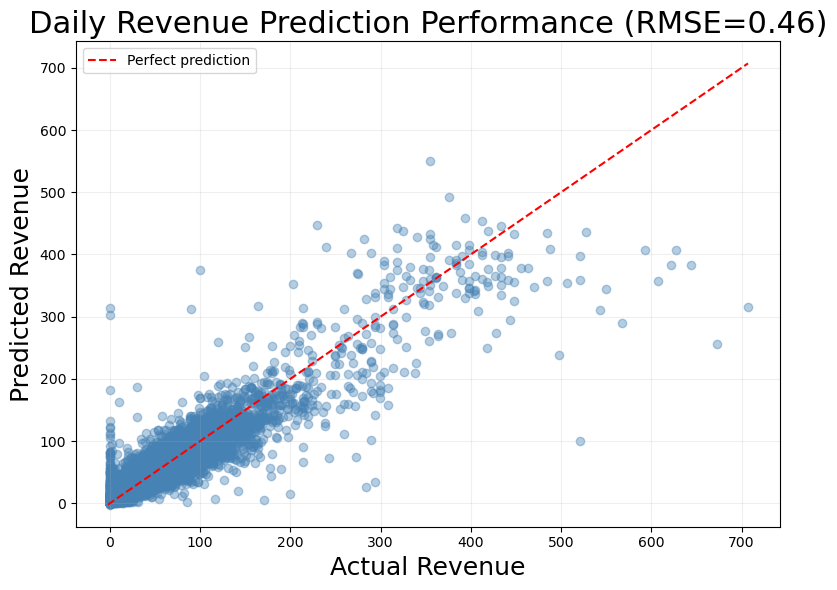

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

plt.figure(figsize=(8,6))

plt.scatter(
    revenue_actual,
    revenue_basepred,
    alpha=0.4,
    color="steelblue"
)

# perfect prediction line
min_val = min(revenue_actual.min(), revenue_basepred.min())
max_val = max(revenue_actual.max(), revenue_basepred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

# RMSE
rmse_rev = np.sqrt(mean_squared_error(revenue_actual, revenue_basepred))

plt.xlabel("Actual Revenue", size=18)
plt.ylabel("Predicted Revenue", size=18)
plt.title(f"Daily Revenue Prediction Performance (RMSE={rel_rmse_revbase:.2f})", size=22)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig("visuals/LightGBMbaseRevenue_Prediction_vsActual.png", dpi=300)

plt.show()

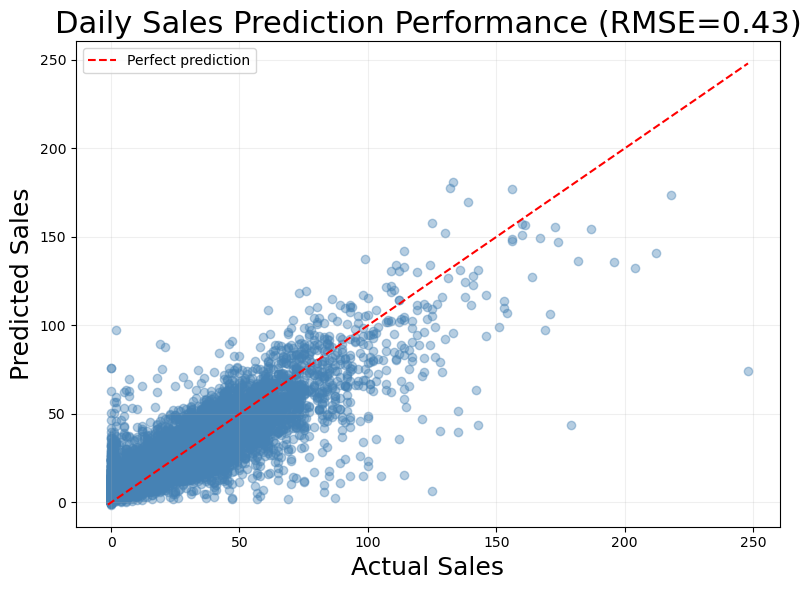

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

plt.figure(figsize=(8,6))

plt.scatter(
    y_test, 
    baseline_pred,
    alpha=0.4,
    color="steelblue"
)

# perfect prediction line
min_val = min(y_test.min(), baseline_pred.min())
max_val = max(y_test.max(), baseline_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

# RMSE
rmse_rev = np.sqrt(mean_squared_error(revenue_actual, revenue_basepred))

plt.xlabel("Actual Sales", size=18)
plt.ylabel("Predicted Sales", size=18)
plt.title(f"Daily Sales Prediction Performance (RMSE={rel_rmse_salesbase:.2f})", size=22)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig("visuals/LightGBMbaseSales_Prediction_vsActual.png", dpi=300)

plt.show()

In [34]:
print(f"Relative RMSE predicted sales: {round(relative_rmse(y_test, baseline_pred), 3)}")
print(f"Relative RMSE predicted revenues: {round(relative_rmse(revenue_actual, revenue_basepred), 3)}")

Relative RMSE predicted sales: 0.435
Relative RMSE predicted revenues: 0.46


In [35]:
#Saving the model for later prediction
import joblib

joblib.dump(baseline_model, "models/lightgbm_model_base.joblib")

['models/lightgbm_model_base.joblib']

## GRIDSEARCH

In [36]:
param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 64],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [37]:
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def relative_rmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / np.mean(y_true)

rrmse_scorer = make_scorer(relative_rmse, greater_is_better=False)

cat_features = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"
]

tscv = TimeSeriesSplit(n_splits=3)

param_grid_small = {
    "n_estimators": [500],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [64, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_gs = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=1
)

grid_search = GridSearchCV(
    estimator=lgbm_gs,
    param_grid=param_grid,
    scoring=rrmse_scorer,
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train,
    categorical_feature=cat_features
)

print("Best params:", grid_search.best_params_)
print("Best CV Relative RMSE:", round(-grid_search.best_score_, 3))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3120
[LightGBM] [Info] Number of data points in the train set: 266608, number of used features: 35
[LightGBM] [Info] Start training from score 28.252408
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'n_estimators': 300, 'num_leaves': 64, 'subsample': 0.8}
Best CV Relative RMSE: 0.513


In [38]:
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

def relative_rmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / np.mean(y_true)

tscv = TimeSeriesSplit(n_splits=3)


sales_daily_scores = []
revenue_daily_scores = []
sales_weekly_scores = []
revenue_weekly_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LGBMRegressor(
        objective="regression",
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1
    )

    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    preds = model.predict(X_val)
    
    # Daily validation dataframe
    
    df_val = X_val.reset_index(drop=True).copy()
    df_val["sales_actual"] = y_val.reset_index(drop=True)
    df_val["sales_pred"] = np.asarray(preds)
    # Daily revenue
    df_val["revenue_actual"] = df_val["sales_actual"] * df_val["sell_price"]
    df_val["revenue_pred"] = df_val["sales_pred"] * df_val["sell_price"]

    # Daily metrics
    
    sales_daily_rrmse = relative_rmse(df_val["sales_actual"], df_val["sales_pred"])
    revenue_daily_rrmse = relative_rmse(df_val["revenue_actual"], df_val["revenue_pred"])

    sales_daily_scores.append(sales_daily_rrmse)
    revenue_daily_scores.append(revenue_daily_rrmse)
    # Weekly aggregation
    # -----------------------------
    weekly_val = (
        df_val
        .groupby(["item_id", "store_id", "wm_yr_wk"], observed=True)
        .agg(
            sales_actual=("sales_actual", "sum"),
            sales_pred=("sales_pred", "sum"),
            revenue_actual=("revenue_actual", "sum"),
            revenue_pred=("revenue_pred", "sum")
        )
        .reset_index()
    )

    # -----------------------------
    # Weekly metrics
    # -----------------------------
    sales_weekly_rrmse = relative_rmse(
        weekly_val["sales_actual"], weekly_val["sales_pred"]
    )
    revenue_weekly_rrmse = relative_rmse(
        weekly_val["revenue_actual"], weekly_val["revenue_pred"]
    )

    sales_weekly_scores.append(sales_weekly_rrmse)
    revenue_weekly_scores.append(revenue_weekly_rrmse)

    print(
        f"Fold {fold}: "
        f"Daily Sales RRMSE={sales_daily_rrmse:.3f}, "
        f"Daily Revenue RRMSE={revenue_daily_rrmse:.3f}, "
        f"Weekly Sales RRMSE={sales_weekly_rrmse:.3f}, "
        f"Weekly Revenue RRMSE={revenue_weekly_rrmse:.3f}"
    )

print("\nMean CV Relative RMSE")
print(f"Daily Sales:   {np.mean(sales_daily_scores):.3f}")
print(f"Daily Revenue: {np.mean(revenue_daily_scores):.3f}")
print(f"Weekly Sales:  {np.mean(sales_weekly_scores):.3f}")
print(f"Weekly Revenue:{np.mean(revenue_weekly_scores):.3f}")



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2961
[LightGBM] [Info] Number of data points in the train set: 66652, number of used features: 34
[LightGBM] [Info] Start training from score 29.388931
Fold 1: Daily Sales RRMSE=0.488, Daily Revenue RRMSE=0.455, Weekly Sales RRMSE=0.189, Weekly Revenue RRMSE=0.188
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3034
[LightGBM] [Info] Number of data points in the train set: 133304, number of used features: 35
[LightGBM] [Info] Start training from score 28.579555
Fold 2: Daily Sales RRMSE=0.400, Daily Revenue RRMSE=0.428, Weekly Sales

- Cross-validation results also show that weekly aggregation substantially improves forecasting accuracy compared to daily predictions. 
- The LightGBM model achieves a mean weekly revenue Relative RMSE of 0.188 across validation folds. When trained on the full training dataset and evaluated on the test set, the model achieves a weekly revenue Relative RMSE - - of 0.172, indicating strong predictive and generalization performance.

* Done: Baseline model (OLS)
* Done: Advanced model (LightGBM)
* Done: Grid Search
* Done: Proper time-series cross-validation
* Done: Test-set evaluation
* Done: Multiple metrics
* Done: Daily vs weekly comparison

## PRICE ELASTICITIES BY ITEM FROM LightGBM

- LightGBM cannot give a coefficient to Price as Linear Regression (like OLS) gives:
- LightGBM learns demand as a nonlinear function: Q=f(P,lags,calendar,store,item,… )
- So there is no single parameter for price.

- But local elasticities can be calculated from the model by simulation.

# Local Elasticites
The standard approach is price perturbation simulation.

For each observation:

-1 predict baseline demand
-2 increase price slightly
-3 recompute predicted demand
-4 calculate elasticity

Elasticity formula:{Delta Q/Q}{\Delta P/P}


In [39]:
import numpy as np
import pandas as pd

def compute_lgbm_price_elasticity(
    model,
    X,
    price_col="sell_price",
    item_col="item_id",
    delta=0.05,
    clip_min_pred=1e-6
):
    """
    Compute point price elasticities from a trained LightGBM model
    using finite differences.

    Parameters
    ----------
    model : fitted model
        Trained LightGBM model.
    X : pd.DataFrame
        Feature matrix used for simulation.
    price_col : str
        Price column name.
    item_col : str
        Item/product ID column name.
    delta : float
        Proportional price shock, e.g. 0.05 = +5%.
    clip_min_pred : float
        Small positive floor to avoid division by zero.

    Returns
    -------
    obs_df : pd.DataFrame
        Observation-level elasticities.
    item_df : pd.DataFrame
        Item-level average elasticities.
    """
    X_base = X.copy()
    X_up = X.copy()

    # Baseline predictions
    q0 = np.asarray(model.predict(X_base), dtype=float)
    q0 = np.clip(q0, clip_min_pred, None)

    # Price increase
    X_up[price_col] = X_up[price_col] * (1 + delta)

    # Recompute dependent price-derived features if they exist
    # Adjust these if your feature engineering uses different names
    if "price_lag_1" in X_up.columns:
        pass  # leave lagged historical price unchanged

    if "price_change_1" in X_up.columns:
        X_up["price_change_1"] = X_up[price_col] - X_up.get("price_lag_1", X_up[price_col])

    if "price_pct_change_1" in X_up.columns:
        denom = X_up.get("price_lag_1", X_up[price_col]).replace(0, np.nan)
        X_up["price_pct_change_1"] = (X_up[price_col] - X_up.get("price_lag_1", X_up[price_col])) / denom
        X_up["price_pct_change_1"] = X_up["price_pct_change_1"].fillna(0)

    if "price_rel" in X_up.columns and "price_roll_mean_28" in X_up.columns:
        denom = X_up["price_roll_mean_28"].replace(0, np.nan)
        X_up["price_rel"] = X_up[price_col] / denom
        X_up["price_rel"] = X_up["price_rel"].fillna(1)

    q1 = np.asarray(model.predict(X_up), dtype=float)
    q1 = np.clip(q1, clip_min_pred, None)

    elasticity = ((q1 - q0) / q0) / delta

    obs_df = pd.DataFrame({
        item_col: X_base[item_col].values,
        "base_price": X_base[price_col].values,
        "q0_pred": q0,
        "q1_pred": q1,
        "elasticity": elasticity
    })

    item_df = (
        obs_df
        .groupby(item_col, observed=True)
        .agg(
            mean_elasticity=("elasticity", "mean"),
            median_elasticity=("elasticity", "median"),
            std_elasticity=("elasticity", "std"),
            n_obs=("elasticity", "size"),
            mean_pred_demand=("q0_pred", "mean"),
            mean_price=("base_price", "mean")
        )
        .reset_index()
        .sort_values("mean_elasticity")
    )

    return obs_df, item_df

In [40]:
# Price elasticities
obs_elast, item_elast = compute_lgbm_price_elasticity(
    model=baseline_model,
    X=X_test.copy(),   # or X_val / latest slice
    price_col="sell_price",
    item_col="item_id",
    delta=0.05
)

print(item_elast.head(10))

        item_id  mean_elasticity  median_elasticity  std_elasticity  n_obs  \
0   FOODS_1_096        -9.676894         -10.519794        5.334537     84   
21  FOODS_3_288        -6.005118          -5.753596        2.346326     84   
27  FOODS_3_377        -5.915087          -5.937255        2.180691    168   
16  FOODS_3_226        -5.627207          -5.866192        2.178750    252   
14  FOODS_3_120        -5.451330          -7.231754        7.100793    252   
45  FOODS_3_694        -5.259802          -5.764613        2.792252    588   
39  FOODS_3_555        -5.157023          -5.406609        3.149153    588   
55  FOODS_3_811        -4.982179          -6.230183        4.144045    168   
18  FOODS_3_252        -4.946218          -5.325137        3.246014    588   
49  FOODS_3_739        -4.770253          -5.601265        2.850189     84   

    mean_pred_demand  mean_price  
0          52.557138    7.230000  
21         35.482964    1.500000  
27         35.593559    1.680000  
1

In [41]:
obs_elast_clean = obs_elast[obs_elast["elasticity"].between(-10, 2)].copy()

item_elast_clean = (
    obs_elast_clean
    .groupby("item_id", observed=True)
    .agg(
        mean_elasticity=("elasticity", "mean"),
        median_elasticity=("elasticity", "median"),
        std_elasticity=("elasticity", "std"),
        n_obs=("elasticity", "size")
    )
    .reset_index()
)

In [42]:
item_elast_clean.head()

,item_id,mean_elasticity,median_elasticity,std_elasticity,n_obs
0,FOODS_1_096,-7.991994,-8.401695,1.990393,33
1,FOODS_1_218,-2.749631,-2.255987,3.017659,54
2,FOODS_2_019,-2.728961,-2.146402,3.382198,71
3,FOODS_2_197,-3.116296,-2.695180,3.273121,136
4,FOODS_2_244,-2.202718,-2.310366,2.066784,72


In [43]:
#Price Simulation
import numpy as np
import pandas as pd

def simulate_item_prices(
    model,
    X,
    item_id,
    price_grid,
    price_col="sell_price",
    item_col="item_id",
    store_col="store_id",
    inventory=None,
    clip_negative_demand=True
):
    """
    Simulate predicted demand and revenue for one item across a grid of prices.

    Parameters
    ----------
    model : fitted LightGBM model
    X : pd.DataFrame
        Feature dataset used for simulation, e.g. X_test or latest slice.
    item_id : str
        Item to simulate.
    price_grid : array-like
        Candidate prices to test.
    price_col : str
        Name of current price column.
    item_col : str
        Name of item ID column.
    store_col : str
        Name of store ID column.
    inventory : float or None
        Optional inventory cap applied to predicted quantity.
    clip_negative_demand : bool
        If True, negative predictions are clipped to 0.

    Returns
    -------
    pd.DataFrame
        One row per candidate price with predicted quantity and revenue.
    """
    subset = X[X[item_col] == item_id].copy()

    if subset.empty:
        raise ValueError(f"No rows found for item_id={item_id}")

    results = []

    for p in price_grid:
        X_sim = subset.copy()

        # set candidate price
        X_sim[price_col] = p

        # update price-derived features if present
        if "price_change_1" in X_sim.columns:
            if "price_lag_1" in X_sim.columns:
                X_sim["price_change_1"] = X_sim[price_col] - X_sim["price_lag_1"]
            else:
                X_sim["price_change_1"] = 0.0

        if "price_pct_change_1" in X_sim.columns:
            if "price_lag_1" in X_sim.columns:
                denom = X_sim["price_lag_1"].replace(0, np.nan)
                X_sim["price_pct_change_1"] = (X_sim[price_col] - X_sim["price_lag_1"]) / denom
                X_sim["price_pct_change_1"] = X_sim["price_pct_change_1"].fillna(0.0)
            else:
                X_sim["price_pct_change_1"] = 0.0

        if "price_rel" in X_sim.columns and "price_roll_mean_28" in X_sim.columns:
            denom = X_sim["price_roll_mean_28"].replace(0, np.nan)
            X_sim["price_rel"] = X_sim[price_col] / denom
            X_sim["price_rel"] = X_sim["price_rel"].fillna(1.0)

        # predict demand
        pred_qty = np.asarray(model.predict(X_sim), dtype=float)

        if clip_negative_demand:
            pred_qty = np.clip(pred_qty, 0, None)

        total_qty = pred_qty.sum()

        # apply inventory cap if provided
        feasible_qty = min(total_qty, inventory) if inventory is not None else total_qty

        revenue = p * feasible_qty

        results.append({
            "item_id": item_id,
            "candidate_price": p,
            "predicted_qty": total_qty,
            "feasible_qty": feasible_qty,
            "predicted_revenue": revenue
        })

    return pd.DataFrame(results)

In [44]:
item_id_example = "FOODS_1_096"

current_price = X_test.loc[X_test["item_id"] == item_id_example, "sell_price"].median()

price_grid = np.round(np.linspace(current_price * 0.8, current_price * 1.2, 9), 2)

sim_df = simulate_item_prices(
    model=baseline_model,
    X=X_test,
    item_id=item_id_example,
    price_grid=price_grid,
    inventory=500
)

print(sim_df.sort_values("predicted_revenue", ascending=False))

       item_id  candidate_price  predicted_qty  feasible_qty  \
8  FOODS_1_096             8.68    2261.627296           500   
7  FOODS_1_096             8.31    2245.731056           500   
6  FOODS_1_096             7.95    2198.315281           500   
5  FOODS_1_096             7.59    2201.216406           500   
4  FOODS_1_096             7.23    4414.799591           500   
3  FOODS_1_096             6.87    1605.116133           500   
2  FOODS_1_096             6.51    1700.185975           500   
1  FOODS_1_096             6.15    1670.348834           500   
0  FOODS_1_096             5.78    1661.927097           500   

   predicted_revenue  
8             4340.0  
7             4155.0  
6             3975.0  
5             3795.0  
4             3615.0  
3             3435.0  
2             3255.0  
1             3075.0  
0             2890.0  


In [45]:
best_price_row = sim_df.loc[sim_df["predicted_revenue"].idxmax()]
print(best_price_row)

item_id              FOODS_1_096
candidate_price             8.68
predicted_qty        2261.627296
feasible_qty                 500
predicted_revenue         4340.0
Name: 8, dtype: object


In [46]:
#Save data for later use in simulators
df_train = X_train.reset_index(drop=True).copy()
df_train["sales"] = y_train.reset_index(drop=True)
df_train.to_csv("data/df_train.csv", index=False)
df_test.to_csv("data/df_test.csv", index=False)

In [47]:
X_train.to_csv("data/X_train.csv", index=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3149
[LightGBM] [Info] Number of data points in the train set: 199956, number of used features: 35
[LightGBM] [Info] Start training from score 29.350782
[CV] END colsample_bytree=0.8, learning_rate=0.03, n_estimators=300, num_leaves=31, subsample=0.8; total time=  23.8s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2961
[LightGBM] [Info] Number of data points in the train set: 66652, number of used features: 34
[LightGBM] [Info] Start training from score 29.388931
[CV] END colsample_bytree=0.8, learning_rate=0.03, n_estimators=500